# DTEx231A. Using LodeSTAR to Detect Particles

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231A_LodeSTAR_autotracker_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

This example ...

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

### 1. Loading an Image of Quantum Dots

???

In [3]:
data = np.load("./assets/image_quantum_dots.npy")

???

In [4]:
data = (data - np.min(data)) / np.ptp(data)

???

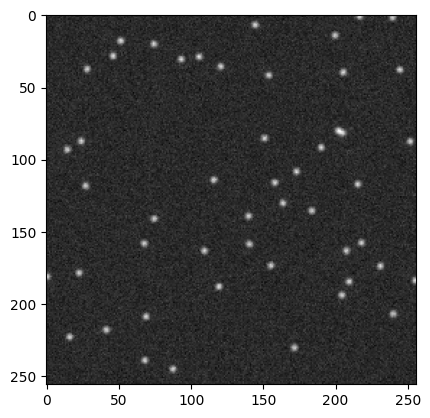

In [5]:
plt.imshow(data[0], cmap="gray")
plt.show()

### 2. Cropping One QUantum Dot

???

In [6]:
crop = data[0, 100:132, 100:132]

???

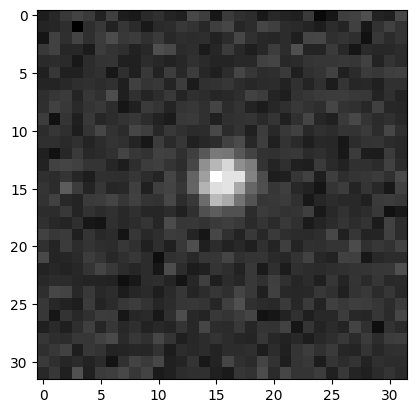

In [7]:
plt.imshow(crop, cmap="gray")

???

### 4. Training LodeSTAR

???

In [8]:
training_data = dt.Value(crop)

dataset = dt.pytorch.Dataset(
    training_data,
    length=128,
)

dataloader = dl.DataLoader(
    dataset=dataset,
    batch_size=4,
)

???

In [9]:
lodestar = dl.LodeSTAR(
    n_transforms=4,
    optimizer=dl.Adam(lr=1e-3),
).build()

???

In [10]:
lodestar_trainer = dl.Trainer(accelerator="auto", max_epochs=50)

/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


???

In [11]:
lodestar_trainer.fit(lodestar, dataloader)

/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:477: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.

  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | model         | ConvolutionalNeuralNetwork | 251 K  | train
1 | between_loss  | L1Loss                     | 0      | train
2 | within_loss   | L1Loss                     | 0      | train
3 | train_metrics | MetricCollection           | 0      

Training: |          | 0/? [00:00<?, ?it/s]

### 5. Testing the Trained Model

???

In [ ]:
data_tensor = torch.from_numpy(data).to(torch.float32).moveaxis(-1, 1)

???

In [14]:
alpha = 0.5
beta = 1 - alpha
cutoff = 0.9

all_detections = lodestar.detect(
    data_tensor, alpha=alpha, beta=beta, cutoff=cutoff, mode="quantile"
)

???

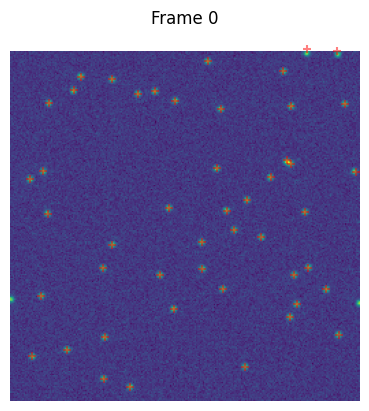

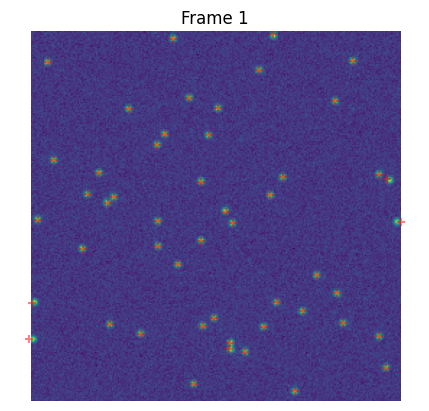

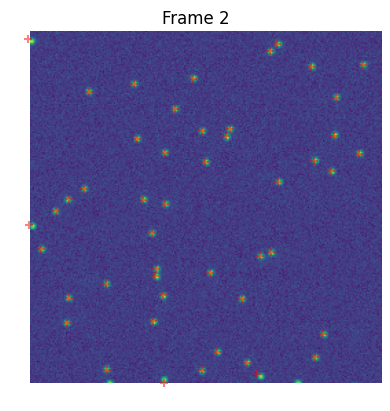

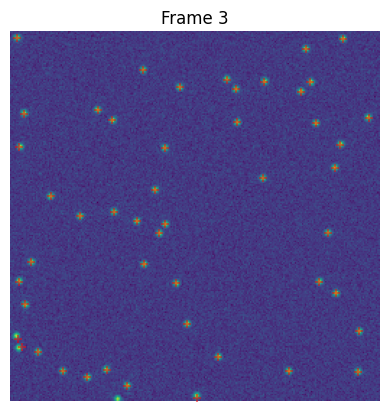

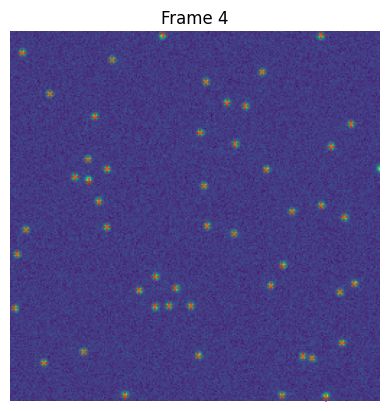

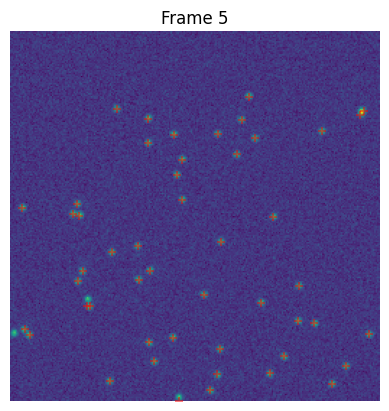

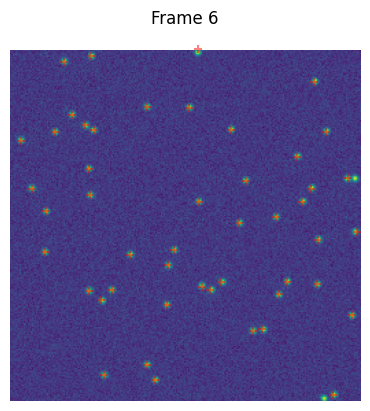

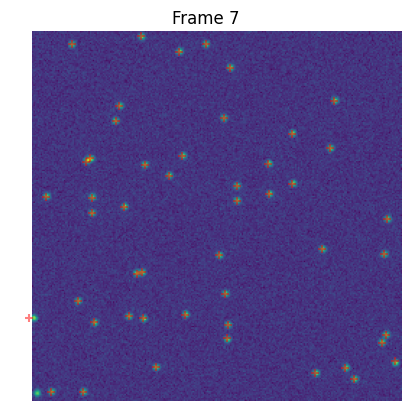

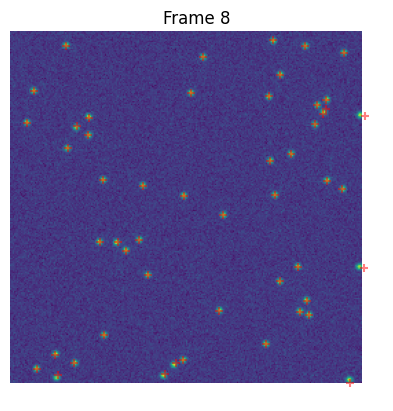

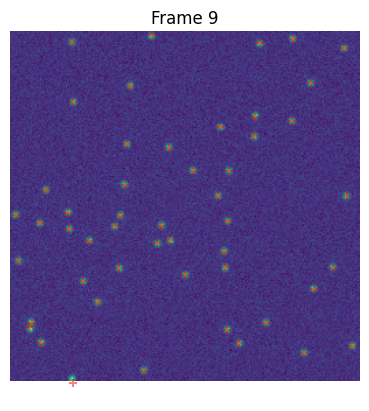

In [20]:
for i, (frame, detections) in enumerate(zip(data_tensor, all_detections)):
    plt.imshow(frame.squeeze(0).detach().cpu())
    plt.scatter(
        detections[:, 1], detections[:, 0], marker="+", c="r", alpha=0.5
    )
    plt.axis("off")
    plt.title(f"Frame {i}")
    plt.show()